# Figure 2 Comparing different pruning methods against independent in-vitro data validates CPC

#### D) Connection probability for 80 μm by 80 μm bins around the presynaptic soma (black triangle), resulting from the in silico experiment outlined in (B). Brown line for unidirectional and coral for reciprocal connectivity. Shaded areas represent boot-strapped 95% confidence intervals

Imports and loading data

In [1]:
from matplotlib import pyplot as plt
import conntility
import numpy
import pandas
import tqdm

from scipy.spatial.distance import pdist, squareform

path = "/Users/natali_obi_account/Desktop/OBI/HUMAN_CORTEX/PAPERS_ON_GOING/CONNECTIVITY_PAPER/code/conn_matrix/Human_NEWfunct_conmat_filtered_compressed.h5"
path = "/Users/mwr/Documents/artefacts/connectomes/Human connectivity paper/Human_NEWfunct_conmat_filtered_compressed.h5"
M = conntility.ConnectivityMatrix.from_h5(path)
M.vertices

,index,population,node_ids,etype,layer,morphology,mtype,synapse_class,x,y,z,ss_flat_x,depth,ss_flat_y
0,0,hncx_neurons,0,PYR_L23,L2,dend-1490_H22.29.223.11.01.02_withcontour_L2_a...,L2_PTPC,EXC,786.699926,2252.921593,1533.098585,1274.699926,355.078407,1557.098585
1,1,hncx_neurons,1,PYR_L23,L2,dend-770658546_L2_axon-689323433_L2_-_Scale_x1...,L2_PTPC,EXC,1073.068353,2244.681839,867.538846,1561.068353,363.318161,891.538846
2,6,hncx_neurons,6,PYR_L23,L2,dend-770275864_L2_axon-689323433_L2_-_Scale_x1...,L2_PTPC,EXC,613.688828,2088.131741,1374.885965,1101.688828,519.868259,1398.885965
3,11,hncx_neurons,11,PYR_L23,L2,dend-707828926_L2_axon-665713811_L2,L2_PTPC,EXC,759.516508,2230.168256,993.011974,1247.516508,377.831744,1017.011974
4,12,hncx_neurons,12,PYR_L23,L2,dend-707828926_L2_axon-0991_H42-06_L2_-_Scale_...,L2_PTPC,EXC,815.300840,2241.759914,1247.501864,1303.300840,366.240086,1271.501864
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20059,106652,hncx_neurons,106652,PYR_L23,L3b,dend-1277_H42_01_(left)_L2_L3_axon-595572609_L...,L3_PC,EXC,928.771581,1589.092459,863.493135,1416.771581,1018.907541,887.493135
20060,106654,hncx_neurons,106654,PYR_L23,L3b,dend-475_H23.29.244.11.31.01_withcontour_L2_L3...,L3_PC,EXC,353.669309,1468.544587,955.963045,841.669309,1139.455413,979.963045
20061,106656,hncx_neurons,106656,PYR_L23,L3b,dend-0925_Rhi13313cell1+2(superficial)_L2_L3_a...,L3_PC,EXC,214.277789,1480.560188,1397.907266,702.277789,1127.439812,1421.907266
20062,106659,hncx_neurons,106659,PYR_L23,L3b,dend-0925_Rhi13313cell1+2(superficial)_L2_L3_a...,L3_PC,EXC,616.886630,1440.170760,1338.233403,1104.886630,1167.829240,1362.233403


Performing in-silico patch-sampling

In [2]:
n_patch=12
n_samples=100
slice_thickness=175
mv_cv = numpy.array([[145**2, 0], [0, 150**2]])
col_slc = ["slice_x", "slice_y"]

def value_deltas(values):
    values = values.to_numpy()
    deltas = values.reshape((-1, 1)) - values.reshape((1, -1))
    return deltas.flatten()

results_dfs = []
for _ in tqdm.tqdm(range(n_samples)):
    try:
        s = M.slice(numpy.random.rand() * numpy.pi, (numpy.random.rand() - 0.5) * 100, slice_thickness)
        s = s.patch_sample(n_patch, [0, 0], mv_cv, columns_xy=col_slc)

        results_dfs.append(pandas.DataFrame(
            {
                "dx": value_deltas(s.vertices["slice_x"]),
                "dy": value_deltas(s.vertices["slice_y"]),
                "dz": value_deltas(s.vertices["slice_depth"]),
                "synapses": s.array.flatten(),
                "synapses_rec": s.to_reciprocal().array.flatten()
            }
        ))
    except:
        pass

DF = pandas.concat(results_dfs, axis=0, names=["sample"], keys=range(len(results_dfs))).reset_index()
DF

100%|██████████| 100/100 [00:07<00:00, 14.01it/s]


,sample,level_1,dx,dy,dz,synapses,synapses_rec
0,0,0,0.000000,0.000000,0.000000,0,0
1,0,1,-164.984203,-71.529502,51.802871,0,0
2,0,2,38.174697,-19.206180,47.931809,0,0
3,0,3,-73.429271,-80.301232,-15.883626,0,0
4,0,4,-123.884941,-44.347382,-42.859997,0,0
...,...,...,...,...,...,...,...
14395,99,139,8.546446,91.267103,49.295990,0,0
14396,99,140,22.050549,101.191797,-99.224458,4,4
14397,99,141,-24.689203,31.506222,-112.534584,0,0
14398,99,142,-2.010685,49.736877,-69.920829,5,0


Creating spatial bins

In [3]:
binning = {
    "vertical": {
        "column": "dy",
        "number": 8,
        "size": 60.0,
        "abs": False
    },
    "horizontal": {
        "column": "dx",
        "number": 6,
        "size": 40.0,
        "abs": True
    },
    "vertical_80": {
        "column": "dy",
        "number": 6,
        "size": 80.0,
        "abs": False
    },
    "horizontal_80": {
        "column": "dx",
        "number": 3,
        "size": 80.0,
        "abs": True
    }
}

def make_bins(specs):
    if (not specs["abs"]):
        n = int(specs["number"] / 2)
        if numpy.mod(specs["number"], 2) == 1:
            bins = (numpy.arange(-n, n + 2) - 0.5) * specs["size"]
        else:
            bins = numpy.arange(-n, n + 1) * specs["size"]
    else:
        bins = numpy.arange(specs["number"] + 1) * specs["size"]
        bins[0] = 0.01
    return bins

def to_binned(specs, df):
    samples = df[specs["column"]]
    bins = make_bins(specs)
    if specs["abs"]:
        samples = numpy.abs(samples)
    binned = numpy.digitize(samples, bins=bins) - 1
    binned[binned >= (len(bins) - 1)] = -1
    return binned, bins

bins = {}
for dim_name, specs in binning.items():
    DF[dim_name], bins[dim_name] = to_binned(specs, DF)

Plotting

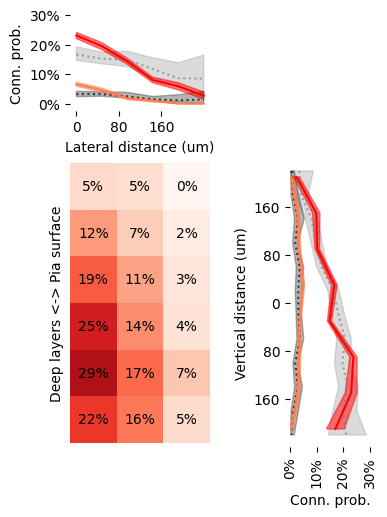

In [4]:
sem = lambda x_: numpy.nanstd(x_) / numpy.sqrt(len(x_))

def upper_lower_bound_polygon(x, y_low, y_up, swap_xy=False, **kwargs):
    from matplotlib import patches
    
    xy = numpy.vstack([
        numpy.vstack([x, y_up]).transpose(),
        numpy.vstack([x, y_low]).transpose()[::-1]
    ])
    if swap_xy:
        xy = xy[:, ::-1]
    return patches.Polygon(xy, **kwargs)

def sem_area_polygon(x, y_mn, y_sem, swap_xy=False, **kwargs):
    return upper_lower_bound_polygon(x, y_mn - y_sem, y_mn + y_sem, swap_xy=swap_xy, **kwargs)

def from_reference_file(fn, **kwargs):
    data = pandas.read_csv(fn)
    x = data["distance_um"].to_numpy()
    y_low = data["lower_pct"].to_numpy()
    y_up = data["upper_pct"].to_numpy()
    polygon = upper_lower_bound_polygon(x, y_low, y_up, **kwargs)
    return data.set_index("distance_um")["mean_pct"], polygon

P = DF.groupby(["vertical_80", "horizontal_80"])["synapses"].apply(lambda x: (x>0).mean()).unstack().drop(index=-1, columns=-1, errors="ignore")

P_vert = DF.groupby(["sample", "vertical"])["synapses"].apply(lambda x: (x>0).mean())
P_vert_mean = P_vert.groupby("vertical").mean().drop(-1, errors="ignore").sort_index()
P_vert_sem = P_vert.groupby("vertical").apply(sem).drop(-1, errors="ignore").sort_index()

P_vert_rec = DF.groupby(["sample", "vertical"])["synapses_rec"].apply(lambda x: (x>0).mean())
P_vert_rec_mean = P_vert_rec.groupby("vertical").mean().drop(-1, errors="ignore").sort_index()
P_vert_rec_sem = P_vert_rec.groupby("vertical").apply(sem).drop(-1, errors="ignore").sort_index()

P_hor = DF.groupby(["sample", "horizontal"])["synapses"].apply(lambda x: (x>0).mean())
P_hor_mean = P_hor.groupby("horizontal").mean().drop(-1, errors="ignore").sort_index()
P_hor_sem = P_hor.groupby("horizontal").apply(sem).drop(-1, errors="ignore").sort_index()

P_hor_rec = DF.groupby(["sample", "horizontal"])["synapses_rec"].apply(lambda x: (x>0).mean())
P_hor_rec_mean = P_hor_rec.groupby("horizontal").mean().drop(-1, errors="ignore").sort_index()
P_hor_rec_sem = P_hor_rec.groupby("horizontal").apply(sem).drop(-1, errors="ignore").sort_index()

fig = plt.figure(figsize=(4, 4.8))

ax = fig.add_axes([0.1, 0.1, 0.35, 0.6])
ax.imshow(P, cmap="Reds", clim=[0, 0.35])
ax.set_xticks([]); ax.set_yticks([])
ax.set_ylabel("Deep layers <-> Pia surface")


for col in P.columns:
    for row in P.index:
        ax.text(col, row, f"{int(numpy.round(100*P[col][row]))}%",
                horizontalalignment="center",
                verticalalignment="center")
ax.set_frame_on(False)


ax = fig.add_axes([0.65, 0.1, 0.2, 0.6])

ref_vert_uni, poly = from_reference_file("./reference_data/peng_con_prob_vertical_unidir.csv", swap_xy=True,
                                         color=[0.6, 0.6, 0.6, 0.35])
ax.add_patch(poly)
ref_vert_bi, poly = from_reference_file("./reference_data/peng_con_prob_vertical_bidir.csv", swap_xy=True,
                                         color=[0.15, 0.15, 0.15, 0.35])
ax.add_patch(poly)

w = 0.5 * (bins["vertical"][:-1] + bins["vertical"][1:])
poly = sem_area_polygon(
    w, 100 * P_vert_mean.to_numpy(), 100 * P_vert_sem.to_numpy(), 
    swap_xy=True, color=[1.0, 0.0, 0.0, 0.5]
)
ax.add_patch(poly)
poly = sem_area_polygon(
    w, 100 * P_vert_rec_mean.to_numpy(), 100 * P_vert_rec_sem.to_numpy(), 
    swap_xy=True, color=[1.0, 0.5, 0.31, 0.5]
)
ax.add_patch(poly)

ax.plot(ref_vert_uni.to_numpy(), ref_vert_uni.index, color="grey", ls=":", alpha=0.7)
ax.plot(ref_vert_bi.to_numpy(), ref_vert_bi.index, color="black", ls=":", alpha=0.7)
ax.plot(100 * P_vert_mean, w, color="red")
ax.plot(100 * P_vert_rec_mean, w, color="coral")

ax.set_ylim(bins["vertical_80"][[-1, 0]])
ax.set_xlim([0, 30])
ax.set_frame_on(False)
ax.set_ylabel("Vertical distance (um)")
ax.set_yticks(bins["vertical_80"].astype(int)[1:-1])
ax.set_yticklabels(numpy.abs(bins["vertical_80"].astype(int)[1:-1]))
ax.set_xlabel("Conn. prob.")
ax.set_xticks([0, 10, 20, 30])
ax.set_xticklabels([f"{int(p)}%" for p in ax.get_xticks()], rotation="vertical")


ax = fig.add_axes([0.1, 0.8, 0.35, 0.2])

ref_hor_uni, poly = from_reference_file("./reference_data/peng_con_prob_horizontal_unidir.csv",
                                         color=[0.6, 0.6, 0.6, 0.35])
ax.add_patch(poly)
ref_hor_bi, poly = from_reference_file("./reference_data/peng_con_prob_horizontal_bidir.csv",
                                         color=[0.15, 0.15, 0.15, 0.35])
ax.add_patch(poly)

# For visual similarity with Peng et al. I "stretch" the plot across the entire range of data sampled
# instead of indicating bin centers. I am convinced that is what Peng et al. did, as they have a data
# point at a distance of 0 um, which is otherwise impossible.
w = numpy.linspace(bins["horizontal"][0], bins["horizontal"][-1], len(P_hor_mean))
poly = sem_area_polygon(
    w, 100 * P_hor_mean.to_numpy(), 100 * P_hor_sem.to_numpy(), 
    color=[1.0, 0.0, 0.0, 0.5]
)
ax.add_patch(poly)
poly = sem_area_polygon(
    w, 100 * P_hor_rec_mean.to_numpy(), 100 * P_hor_rec_sem.to_numpy(), 
    color=[1.0, 0.5, 0.31, 0.5]
)
ax.add_patch(poly)

ax.plot(ref_hor_uni.index, ref_hor_uni.to_numpy(),  color="grey", ls=":", alpha=0.7)
ax.plot(ref_hor_bi.index, ref_hor_bi.to_numpy(), color="black", ls=":", alpha=0.7)
ax.plot(w, 100 * P_hor_mean, color="red")
ax.plot(w, 100 * P_hor_rec_mean, color="coral")
ax.set_ylim([-2.5, numpy.max(ax.get_ylim())])
ax.set_frame_on(False)
ax.set_xlabel("Lateral distance (um)")
ax.set_xticks(bins["horizontal_80"].astype(int)[:-1])
ax.set_ylabel("Conn. prob.")
ax.set_yticks(ax.get_yticks()[1:])
ax.set_yticklabels([f"{int(p)}%" for p in ax.get_yticks()])

fig.savefig("compare_peng_2b.png")
fig.savefig("compare_peng_2b.pdf")
